### Part 1 — Data Understanding & Exploration
Perform basic data exploration and preprocessing.

#### Tasks
1. Load the dataset using Pandas.
2. Explore the dataset structure:
   - a. Shape of the dataset
   - b. Column names
   - c. Data types
   - d. Missing values
3. Identify duplicate records (if any).
4. Convert the "Average Cost for two" column into an appropriate numeric data type (if required).
5. Perform basic statistical analysis using appropriate Pandas functions.
6. Answer the following questions:
   - a. How many unique cities are present in the dataset?
   - b. Which city has the highest number of restaurants?
   - c. Which cuisine appears most frequently?

In [1]:
# 1) Load required libraries and dataset
import pandas as pd
import numpy as np

file_path = 'content/test_zomato.csv'
df = pd.read_csv(file_path)

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully.
Shape: (9552, 22)


,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [2]:
# 2) Explore dataset structure
print('Shape of dataset:', df.shape)

print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values by column:')
missing_values = df.isnull().sum()
print(missing_values)

missing_percent = (missing_values / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

missing_summary

Shape of dataset: (9552, 22)

Column names:
['Unnamed: 0', 'Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data types:
Unnamed: 0                  str
Restaurant ID               str
Restaurant Name             str
Country Code            float64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude                   str
Latitude                    str
Cuisines                    str
Average Cost for two        str
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range             float64
Aggregate ra

,Missing Count,Missing Percentage
Cuisines,10,0.10
Price range,2,0.02
Votes,2,0.02
Rating text,2,0.02
Rating color,2,0.02
Aggregate rating,2,0.02
Has Table booking,1,0.01
Currency,1,0.01
Average Cost for two,1,0.01
Latitude,1,0.01


In [3]:
# 3) Identify duplicate records
duplicate_count = df.duplicated().sum()
print(f'Total duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    print('\nSample duplicate rows:')
    display(df[df.duplicated()].head())
else:
    print('No duplicate records found.')

Total duplicate rows: 0
No duplicate records found.


In [4]:
# 4) Convert 'Average Cost for two' to numeric
col = 'Average Cost for two'
before_dtype = df[col].dtype

# Remove commas/spaces and convert safely to numeric
df[col] = pd.to_numeric(
    df[col].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)

after_dtype = df[col].dtype
new_nulls = df[col].isnull().sum()

print(f"Data type before conversion: {before_dtype}")
print(f"Data type after conversion: {after_dtype}")
print(f"Null values in '{col}' after conversion: {new_nulls}")

df[[col]].head()

Data type before conversion: str
Data type after conversion: float64
Null values in 'Average Cost for two' after conversion: 2


,Average Cost for two
0,1100.0
1,1200.0
2,4000.0
3,1500.0
4,1500.0


In [5]:
# 5) Basic statistical analysis
print('Numeric column summary statistics:')
display(df.describe(include=[np.number]).T)

print('\nCategorical column summary statistics:')
display(df.describe(include=['str']).T)

Numeric column summary statistics:


,count,mean,std,min,25%,50%,75%,max
Country Code,9552.0,18.374564,56.754313,1.0,1.0,1.0,1.0,216.0
Average Cost for two,9550.0,1199.326387,16122.023220,0.0,250.0,400.0,700.0,800000.0
Price range,9550.0,1.804607,0.905378,1.0,1.0,2.0,2.0,4.0
Aggregate rating,9550.0,2.666314,1.516447,0.0,2.5,3.2,3.7,4.9
Votes,9550.0,156.923037,430.189709,0.0,5.0,31.0,131.0,10934.0



Categorical column summary statistics:


,count,unique,top,freq
Unnamed: 0,9552,9552,0,1
Restaurant ID,9552,9552,6317637,1
Restaurant Name,9552,7447,Cafe Coffee Day,83
City,9552,142,New Delhi,5473
Address,9552,8919,"Dilli Haat, INA, New Delhi",11
Locality,9551,1208,Connaught Place,122
Locality Verbose,9551,1265,"Connaught Place, New Delhi",122
Longitude,9551,8120,0.0,498
Latitude,9551,8677,0.0,498
Cuisines,9542,1826,North Indian,936


In [6]:
# 6) Required questions and direct answers
unique_cities = df['City'].nunique(dropna=True)
top_city = df['City'].value_counts().idxmax()
top_city_count = df['City'].value_counts().max()

# For cuisine frequency, split multi-cuisine rows and count each cuisine separately
all_cuisines = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
top_cuisine = all_cuisines.value_counts().idxmax()
top_cuisine_count = all_cuisines.value_counts().max()

print(f"a) Number of unique cities: {unique_cities}")
print(f"b) City with highest number of restaurants: {top_city} ({top_city_count} restaurants)")
print(f"c) Most frequent cuisine: {top_cuisine} ({top_cuisine_count} occurrences)")

a) Number of unique cities: 142
b) City with highest number of restaurants: New Delhi (5473 restaurants)
c) Most frequent cuisine: North Indian (3960 occurrences)


### Part 2 — Data Analysis
Analyze the dataset to answer the following questions.

#### Tasks
1. Find the average restaurant rating.
2. Identify the restaurant with the highest number of votes.
3. Find the average cost for two across all restaurants.
4. Compare the average ratings of restaurants that:
   - a. Have Online Delivery
   - b. Do Not Have Online Delivery
5. Compare the average ratings of restaurants that:
   - a. Have Table Booking
   - b. Do Not Have Table Booking
6. Identify the top 10 cities with the highest number of restaurants.

In [7]:
# Part 2.1 to 2.3: core summary metrics 
aggregate_rating_num = pd.to_numeric(df['Aggregate rating'], errors='coerce')
avg_rating = aggregate_rating_num.mean()

avg_cost_series = pd.to_numeric(
    df['Average Cost for two'].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
avg_cost_for_two = avg_cost_series.mean()

votes_numeric = pd.to_numeric(df['Votes'], errors='coerce')
top_votes_idx = votes_numeric.idxmax()
top_voted_restaurant = df.loc[top_votes_idx, 'Restaurant Name']
top_voted_city = df.loc[top_votes_idx, 'City']
top_votes_value = int(votes_numeric.loc[top_votes_idx])

print(f"1) Average restaurant rating: {avg_rating:.2f}")
print(f"2) Restaurant with highest votes: {top_voted_restaurant} ({top_votes_value} votes, {top_voted_city})")
print(f"3) Average cost for two across all restaurants: {avg_cost_for_two:.2f}")

1) Average restaurant rating: 2.67
2) Restaurant with highest votes: Toit (10934 votes, Bangalore)
3) Average cost for two across all restaurants: 1199.33


In [8]:
# Part 2.4 and 2.5: rating comparisons by service features
online_delivery_ratings = (
    df.assign(online=df['Has Online delivery'].astype(str).str.strip())
      .loc[lambda x: x['online'].isin(['Yes', 'No'])]
      .groupby('online')['Aggregate rating']
      .mean()
      .rename(index={'Yes': 'Has Online Delivery', 'No': 'No Online Delivery'})
)

table_booking_ratings = (
    df.assign(table_booking=df['Has Table booking'].astype(str).str.strip())
      .loc[lambda x: x['table_booking'].isin(['Yes', 'No'])]
      .groupby('table_booking')['Aggregate rating']
      .mean()
      .rename(index={'Yes': 'Has Table Booking', 'No': 'No Table Booking'})
)

comparison_df = pd.concat([
    online_delivery_ratings.rename('Avg Rating'),
    table_booking_ratings.rename('Avg Rating')
]).round(3)

print('4) Average ratings by Online Delivery:')
display(online_delivery_ratings.round(3).to_frame('Avg Rating'))

print('5) Average ratings by Table Booking:')
display(table_booking_ratings.round(3).to_frame('Avg Rating'))

4) Average ratings by Online Delivery:


,Avg Rating
online,
No Online Delivery,2.465
Has Online Delivery,3.249


5) Average ratings by Table Booking:


,Avg Rating
table_booking,
No Table Booking,2.559
Has Table Booking,3.442


In [9]:
# Part 2.6: top 10 cities by restaurant count
top_10_cities = df['City'].value_counts().head(10).rename_axis('City').reset_index(name='Restaurant Count')

print('6) Top 10 cities with highest number of restaurants:')
display(top_10_cities)

6) Top 10 cities with highest number of restaurants:


,City,Restaurant Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Ahmedabad,21
6,Amritsar,21
7,Bhubaneshwar,21
8,Guwahati,21
9,Lucknow,21


### Part 3 — Data Visualization
Create appropriate visualizations using Matplotlib and/or Seaborn.

#### Tasks
Create the following charts:
1. Bar Chart
   - a. Top 10 cities with the highest number of restaurants.
2. Histogram
   - a. Distribution of Aggregate Ratings.
3. Bar Chart
   - a. Number of restaurants offering Online Delivery (Yes/No).
4. Bar Chart
   - a. Top 10 most common cuisines.
5. Line Chart
   - a. Average restaurant rating by Price Range.

In [10]:
# Part 3 setup: plotting libraries and reusable cleaned series
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

rating_series = pd.to_numeric(df['Aggregate rating'], errors='coerce')
price_range_series = pd.to_numeric(df['Price range'], errors='coerce')
online_delivery_series = df['Has Online delivery'].astype(str).str.strip()

cuisine_series = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .replace('', np.nan)
    .dropna()
)

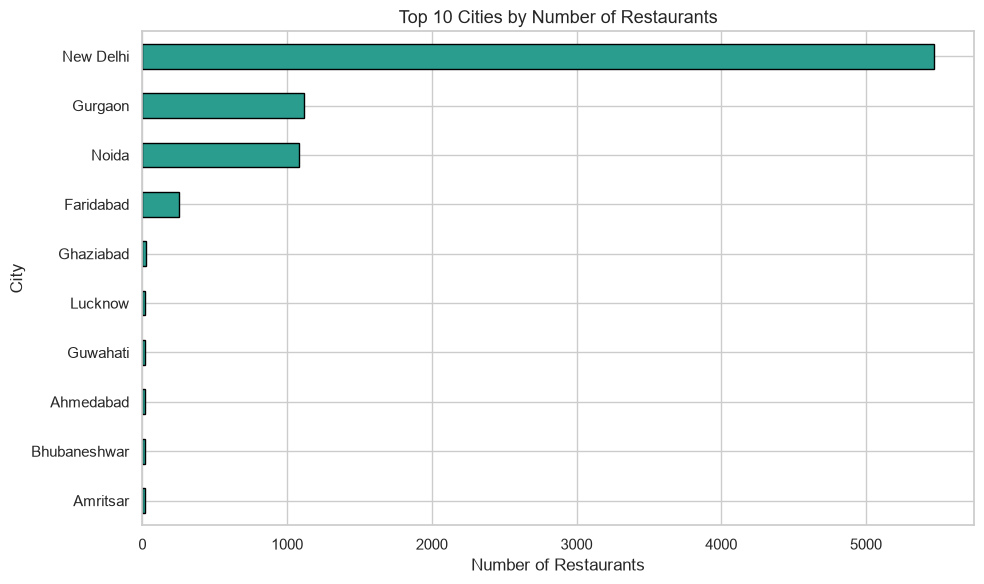

In [11]:
# Chart 1: Top 10 cities with the highest number of restaurants
top_10_city_counts = df['City'].value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = top_10_city_counts.plot(kind='barh', color='#2A9D8F', edgecolor='black')
ax.set_title('Top 10 Cities by Number of Restaurants', fontsize=13)
ax.set_xlabel('Number of Restaurants')
ax.set_ylabel('City')
plt.tight_layout()
plt.show()

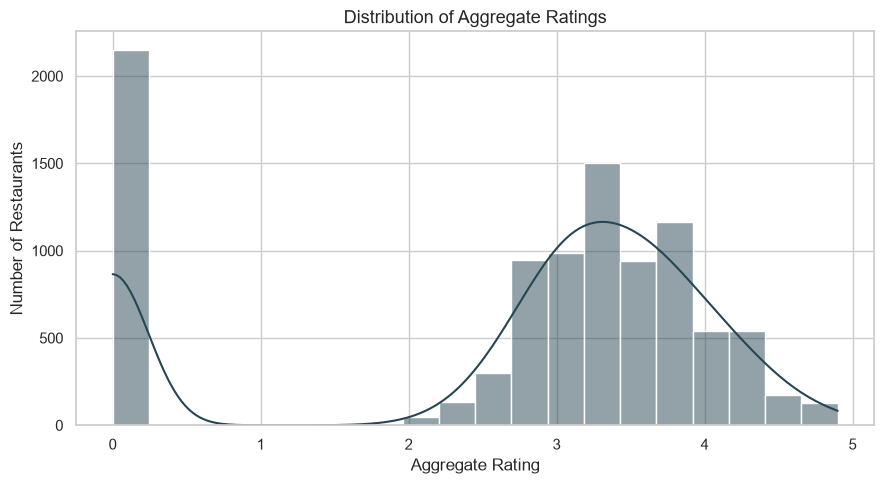

In [12]:
# Chart 2: Distribution of Aggregate Ratings
plt.figure(figsize=(9, 5))
sns.histplot(rating_series.dropna(), bins=20, kde=True, color='#264653', edgecolor='white')
plt.title('Distribution of Aggregate Ratings', fontsize=13)
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

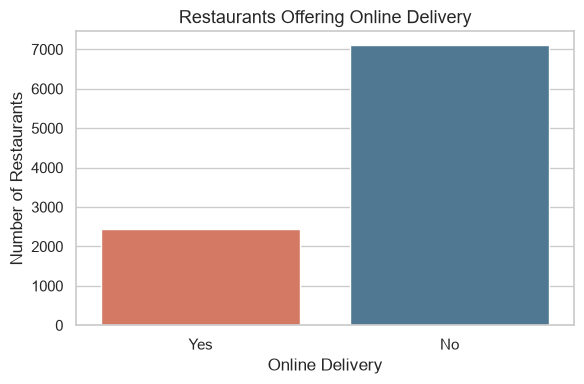

In [13]:
# Chart 3: Number of restaurants offering Online Delivery (Yes/No)
online_counts = online_delivery_series[online_delivery_series.isin(['Yes', 'No'])].value_counts()
online_counts = online_counts.reindex(['Yes', 'No'])

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=online_counts.index, y=online_counts.values, hue=online_counts.index, palette=['#E76F51', '#457B9D'], legend=False)
ax.set_title('Restaurants Offering Online Delivery', fontsize=13)
ax.set_xlabel('Online Delivery')
ax.set_ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

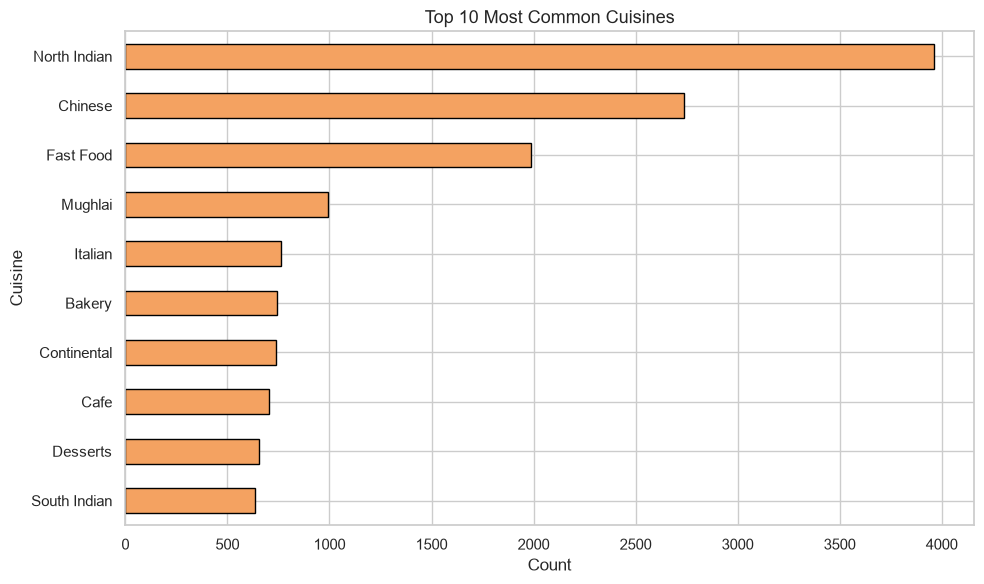

In [14]:
# Chart 4: Top 10 most common cuisines
top_10_cuisines = cuisine_series.value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = top_10_cuisines.plot(kind='barh', color='#F4A261', edgecolor='black')
ax.set_title('Top 10 Most Common Cuisines', fontsize=13)
ax.set_xlabel('Count')
ax.set_ylabel('Cuisine')
plt.tight_layout()
plt.show()

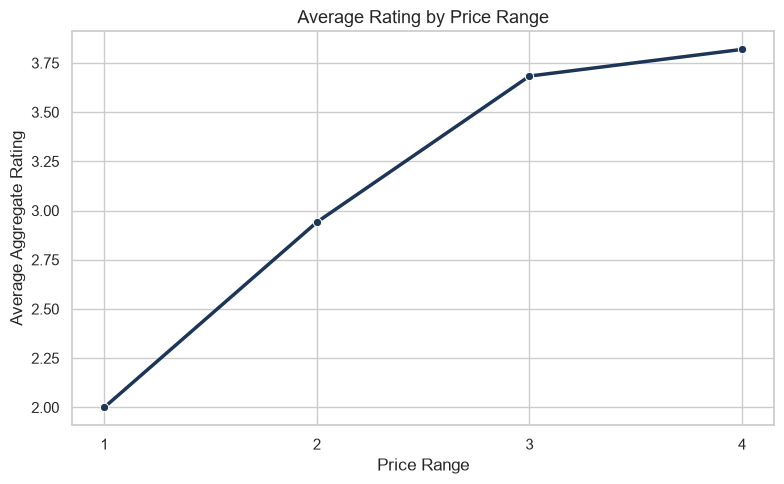

In [15]:
# Chart 5: Average restaurant rating by Price Range
price_rating = (
    df.assign(
        price_range_num=price_range_series,
        aggregate_rating_num=rating_series
    )
    .dropna(subset=['price_range_num', 'aggregate_rating_num'])
    .groupby('price_range_num')['aggregate_rating_num']
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
ax = sns.lineplot(x=price_rating.index, y=price_rating.values, marker='o', linewidth=2.5, color='#1D3557')
ax.set_title('Average Rating by Price Range', fontsize=13)
ax.set_xlabel('Price Range')
ax.set_ylabel('Average Aggregate Rating')
plt.xticks(sorted(price_rating.index.astype(int)))
plt.tight_layout()
plt.show()

### Part 4 — Insights & Conclusion
Based on your analysis, answer the following:
1. Which city has the highest restaurant presence?
2. What is the most popular cuisine?
3. Do restaurants with Online Delivery generally have higher ratings?
4. Do restaurants offering Table Booking receive better ratings?
5. What did you learn from analyzing this dataset?

In [16]:
# Part 4: Final answers
city_counts = df['City'].value_counts()
part4_top_city = city_counts.idxmax()
part4_top_city_count = int(city_counts.max())

split_cuisines = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
part4_top_cuisine = split_cuisines.value_counts().idxmax()
part4_top_cuisine_count = int(split_cuisines.value_counts().max())

rating_num = pd.to_numeric(df['Aggregate rating'], errors='coerce')

online_rating = (
    pd.DataFrame({
        'online': df['Has Online delivery'].astype(str).str.strip(),
        'rating': rating_num
    })
    .loc[lambda x: x['online'].isin(['Yes', 'No'])]
    .groupby('online')['rating']
    .mean()
)

table_rating = (
    pd.DataFrame({
        'table': df['Has Table booking'].astype(str).str.strip(),
        'rating': rating_num
    })
    .loc[lambda x: x['table'].isin(['Yes', 'No'])]
    .groupby('table')['rating']
    .mean()
)

online_yes = float(online_rating.get('Yes', np.nan))
online_no = float(online_rating.get('No', np.nan))
table_yes = float(table_rating.get('Yes', np.nan))
table_no = float(table_rating.get('No', np.nan))

print('1) Which city has the highest restaurant presence?')
print(f'   {part4_top_city} ({part4_top_city_count} restaurants)')
print()
print('2) What is the most popular cuisine?')
print(f'   {part4_top_cuisine} ({part4_top_cuisine_count} occurrences)')
print()
print('3) Do restaurants with Online Delivery generally have higher ratings?')
print(f'   Yes: {online_yes:.3f} | No: {online_no:.3f}')
print('   Conclusion: Yes, restaurants with online delivery have higher average ratings.')
print()
print('4) Do restaurants offering Table Booking receive better ratings?')
print(f'   Yes: {table_yes:.3f} | No: {table_no:.3f}')
print('   Conclusion: Yes, table-booking restaurants have higher average ratings.')
print()
print('5) What did we learn from this dataset?')
print('- Restaurant presence is highly concentrated in a few NCR cities, especially New Delhi.')
print('- North Indian cuisine dominates customer-facing restaurant offerings.')
print('- Service features (online delivery and table booking) are associated with better average ratings.')
print('- Higher price ranges tend to correspond with higher average customer ratings.')

1) Which city has the highest restaurant presence?
   New Delhi (5473 restaurants)

2) What is the most popular cuisine?
   North Indian (3960 occurrences)

3) Do restaurants with Online Delivery generally have higher ratings?
   Yes: 3.249 | No: 2.465
   Conclusion: Yes, restaurants with online delivery have higher average ratings.

4) Do restaurants offering Table Booking receive better ratings?
   Yes: 3.442 | No: 2.559
   Conclusion: Yes, table-booking restaurants have higher average ratings.

5) What did we learn from this dataset?
- Restaurant presence is highly concentrated in a few NCR cities, especially New Delhi.
- North Indian cuisine dominates customer-facing restaurant offerings.
- Service features (online delivery and table booking) are associated with better average ratings.
- Higher price ranges tend to correspond with higher average customer ratings.
